# Preprocessing Data Oligohydramnion

Notebook ini menyiapkan data mentah pasien menjadi dataset numerik dan ternormalisasi sesuai `rule-fcm.md` serta struktur output yang sudah ada di folder `outputs`.

In [22]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

RAW_DATA_PATH = DATA_DIR / "data_pasien.csv"
FEATURE_COLUMNS = [
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
REQUIRED_COLUMNS = [
    "No",
    "Nomor RM",
    "Usia Ibu",
    "Usia Kehamilan",
    "Gravida",
    "Tekanan Darah",
    "Denyut Jantung Janin",
    "Nilai AFI",
    "Kejadian KPD",
]
COLUMN_ALIASES = {
    "Kejadian Ketuban Pecah Dini": "Kejadian KPD",
    "Kejadian kpd": "Kejadian KPD",
    "Nomor Rekam Medis": "Nomor RM",
}

In [23]:
def clean_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return ""
    return text

def remove_mow_text(value):
    text = clean_text(value)
    if not text:
        return ""
    parts = [part.strip() for part in text.replace("+", ",").split(",")]
    parts = [part for part in parts if part and part.lower() != "mow"]
    return ", ".join(parts)

def parse_numeric(value):
    text = clean_text(value)
    if not text:
        return None
    text = text.replace(",", ".")
    try:
        return float(text)
    except ValueError:
        return None

def normalize_rm(value):
    text = clean_text(value)
    if not text:
        return ""
    compact = text.replace(" ", "")
    numeric = compact.replace(".0", "")
    if numeric.isdigit():
        return numeric.zfill(6)
    return compact

def parse_range_numeric(value):
    text = clean_text(value)
    if not text:
        return None
    text = text.replace("–", "-").replace("—", "-").replace(" ", "")
    if "-" in text:
        parts = [part for part in text.split("-") if part]
        numbers = []
        for part in parts:
            try:
                numbers.append(float(part.replace(",", ".")))
            except ValueError:
                return None
        if numbers:
            return float(sum(numbers) / len(numbers))
        return None
    return parse_numeric(text)

def parse_blood_pressure(value):
    text = clean_text(value)
    if not text:
        return None, None, None
    text = text.replace(" ", "")
    match = re.match(r"^(\d{2,3})/(\d{2,3})$", text)
    if not match:
        return None, None, None
    systolic = int(match.group(1))
    diastolic = int(match.group(2))
    if 160 <= systolic <= 180:
        attr = 3
    elif systolic >= 140 or diastolic >= 90:
        attr = 2
    elif systolic < 140 and diastolic < 90:
        attr = 1
    else:
        attr = None
    return attr, systolic, diastolic

def transform_gravida(value):
    number = parse_numeric(value)
    if number is None:
        return None, None
    return (1 if number == 1 else 2), float(number)

def transform_djj(value):
    number = parse_numeric(value)
    if number is None:
        return None, None
    if 120 <= number <= 160:
        attr = 0
    else:
        attr = 1
    return attr, float(number)

def transform_kpd(value):
    text = clean_text(value).lower()
    if not text:
        return None
    if text == "tidak":
        return 1
    if text == "ada":
        return 0
    return None

def minmax_normalize(series, min_value, max_value):
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return series.astype(float) * 0.0
    return (series.astype(float) - min_value) / (max_value - min_value)

def standardize_columns(df):
    renamed = []
    for column in df.columns:
        clean_column = clean_text(column)
        renamed.append(COLUMN_ALIASES.get(clean_column, clean_column or column))
    df = df.copy()
    df.columns = renamed
    for column in [*REQUIRED_COLUMNS, "Tindakan"]:
        if column not in df.columns:
            df[column] = np.nan
    return df

def transform_rows(raw_df):
    records = []
    original_columns = list(raw_df.columns)
    for _, row in raw_df.iterrows():
        record = {column: row.get(column, np.nan) for column in original_columns}
        reasons = []
        no_value = parse_numeric(row.get("No"))
        nomor_rm = normalize_rm(row.get("Nomor RM"))
        usia_ibu = parse_numeric(row.get("Usia Ibu"))
        usia_kehamilan = parse_range_numeric(row.get("Usia Kehamilan"))
        gravida_attr, gravida_raw = transform_gravida(row.get("Gravida"))
        tekanan_attr, systolic, diastolic = parse_blood_pressure(row.get("Tekanan Darah"))
        djj_attr, djj_raw = transform_djj(row.get("Denyut Jantung Janin"))
        nilai_afi = parse_numeric(row.get("Nilai AFI"))
        kpd_attr = transform_kpd(row.get("Kejadian KPD"))
        tindakan_val = remove_mow_text(row.get("Tindakan"))
        if no_value is None:
            reasons.append("No kosong")
        if not nomor_rm:
            reasons.append("Nomor RM kosong")
        if usia_ibu is None:
            reasons.append("Usia Ibu tidak valid/kosong")
        if usia_kehamilan is None:
            reasons.append("Usia Kehamilan tidak valid/kosong")
        if gravida_attr is None:
            reasons.append("Gravida tidak valid/kosong")
        if tekanan_attr is None:
            reasons.append("Tekanan Darah tidak valid/kosong")
        if djj_attr is None:
            reasons.append("Denyut Jantung Janin tidak valid/kosong")
        if nilai_afi is None:
            reasons.append("Nilai AFI tidak valid/kosong")
        if kpd_attr is None:
            reasons.append("Kejadian KPD tidak valid/kosong")
        if not tindakan_val:
            reasons.append("Tindakan tidak valid/kosong")
        record["No"] = int(no_value) if no_value is not None else np.nan
        record["Nomor RM"] = nomor_rm or np.nan
        record["Usia Ibu"] = usia_ibu if usia_ibu is not None else np.nan
        record["Usia Kehamilan"] = usia_kehamilan if usia_kehamilan is not None else np.nan
        record["Gravida"] = gravida_attr if gravida_attr is not None else np.nan
        record["Tekanan Darah"] = tekanan_attr if tekanan_attr is not None else np.nan
        record["Denyut Jantung Janin"] = djj_attr if djj_attr is not None else np.nan
        record["Nilai AFI"] = nilai_afi if nilai_afi is not None else np.nan
        record["Kejadian KPD"] = kpd_attr if kpd_attr is not None else np.nan
        record["Tindakan"] = tindakan_val or np.nan
        record["Gravida Asli"] = gravida_raw if gravida_raw is not None else np.nan
        record["Denyut Jantung Janin Asli"] = djj_raw if djj_raw is not None else np.nan
        record["Sistolik"] = systolic if systolic is not None else np.nan
        record["Diastolik"] = diastolic if diastolic is not None else np.nan
        record["Status Validasi"] = "valid" if not reasons else "invalid"
        record["Alasan Invalid"] = "; ".join(reasons)
        records.append(record)
    return pd.DataFrame(records)

def build_normalized_outputs(valid_df):
    min_values = valid_df[FEATURE_COLUMNS].min().to_dict()
    max_values = valid_df[FEATURE_COLUMNS].max().to_dict()
    normalized = valid_df.copy()
    for column in FEATURE_COLUMNS:
        normalized[column] = minmax_normalize(normalized[column], min_values[column], max_values[column])
    output_preprocessing = normalized[["No", "Nomor RM", *FEATURE_COLUMNS]].copy()
    output_detail = normalized[
        [
            "No",
            "Nomor RM",
            "Tindakan",
            "Gravida Asli",
            "Sistolik",
            "Diastolik",
            *FEATURE_COLUMNS,
        ]
    ].copy()
    output_preprocessing["No"] = output_preprocessing["No"].astype(int)
    output_detail["No"] = output_detail["No"].astype(int)
    output_preprocessing["Nomor RM"] = output_preprocessing["Nomor RM"].astype(str)
    output_detail["Nomor RM"] = output_detail["Nomor RM"].astype(str)
    return output_preprocessing, output_detail, min_values, max_values

def visualize_identifikasi(df):
    """
    Menghasilkan grafik bar chart untuk identifikasi berbagai kategori pasien.
    Individual charts saved separately, and a single horizontal combined chart saved as visualisasi_identifikasi_gabungan.png.
    """
    sns.set_theme(style="whitegrid")
    plt.rcParams["figure.dpi"] = 150
    plot_df_all = df.copy()
    total_data = len(plot_df_all)

    # 1. Usia Ibu
    age_bins = [0, 19, 35, 100]
    age_labels = ["< 20", "20-35", "> 35"]
    plot_df_all["Usia Ibu Cat"] = pd.cut(
        plot_df_all["Usia Ibu"], bins=age_bins, labels=age_labels
    )

    # 2. Usia Kehamilan
    uk_bins = [0, 36.9, 42, 100]
    uk_labels = ["< 37 minggu", "37-42 minggu", "> 42 minggu"]
    plot_df_all["Usia Kehamilan Cat"] = pd.cut(
        plot_df_all["Usia Kehamilan"], bins=uk_bins, labels=uk_labels
    )

    # 3. Gravida
    plot_df_all["Gravida Cat"] = plot_df_all["Gravida Asli"].apply(
        lambda x: "Primigravida" if x == 1 else "Multigravida"
    )

    # 4. Tekanan Darah
    td_map = {1: "< 140/90 mmHg", 2: "≥ 140/90 mmHg", 3: "160-180 mmHg"}
    plot_df_all["Tekanan Darah Cat"] = plot_df_all["Tekanan Darah"].map(td_map)

    # 5. DJJ
    plot_df_all["DJJ Cat"] = plot_df_all["Denyut Jantung Janin Asli"].apply(
        lambda x: "120–160 x/menit" if 120 <= x <= 160 else "<120 atau >160 x/menit"
    )

    # 6. AFI
    afi_labels = ["0-1", "1.1-2", "2.1-3", "3.1-4", "4.1-5"]
    plot_df_all["AFI Cat"] = pd.cut(
        plot_df_all["Nilai AFI"], bins=[-0.1, 1, 2, 3, 4, 5], labels=afi_labels
    )

    # 7. KPD
    plot_df_all["KPD Cat"] = plot_df_all["Kejadian KPD"].map({0: "Ada", 1: "Tidak Ada"})

    categories = [
        ("Usia Ibu Cat", "Identifikasi Usia Ibu"),
        ("Usia Kehamilan Cat", "Identifikasi Usia Kehamilan"),
        ("Gravida Cat", "Identifikasi Gravida"),
        ("Tekanan Darah Cat", "Identifikasi Tekanan Darah"),
        ("DJJ Cat", "Identifikasi Denyut Jantung Janin (DJJ)"),
        ("AFI Cat", "Identifikasi Amniotic Fluid Index (AFI)"),
        ("KPD Cat", "Identifikasi Kejadian Ketuban Pecah Dini (KPD)"),
    ]

    all_stats = []
    for col, title in categories:
        counts = plot_df_all[col].value_counts().sort_index()
        temp_df_list = []
        for cat, val in counts.items():
            stat = {
                "Kategori": str(cat),
                "Jumlah": val,
                "Persen": round(val / total_data * 100, 2),
                "Variabel": title
            }
            all_stats.append(stat)
            temp_df_list.append(stat)
        
        total_stat = {"Kategori": "Total", "Jumlah": total_data, "Persen": 100.0, "Variabel": title}
        all_stats.append(total_stat)
        temp_df_list.append(total_stat)
        
        plot_df = pd.DataFrame(temp_df_list)
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x="Kategori", y="Jumlah", data=plot_df, hue="Kategori", palette="viridis", legend=False)
        plt.title(title, fontsize=14, fontweight="bold")
        plt.ylabel("Jumlah Data")
        plt.ylim(0, total_data * 1.2)
        for i, p in enumerate(ax.patches):
            height = p.get_height()
            if i < len(plot_df):
                val = plot_df.iloc[i]["Jumlah"]
                pct = plot_df.iloc[i]["Persen"]
                ax.annotate(f"{int(val)}\n({pct}%)", (p.get_x() + p.get_width() / 2.0, height),
                            ha="center", va="center", xytext=(0, 10), textcoords="offset points",
                            fontsize=10, fontweight="bold")
        plt.tight_layout()
        filename = title.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".png"
        plt.savefig(OUTPUT_DIR / filename)
        plt.close()

    full_df = pd.DataFrame(all_stats)
    full_df["Kategori Tampilan"] = full_df.apply(
        lambda r: f"{r['Kategori']} ({r['Variabel'].replace('Identifikasi ', '')})" if r['Kategori'] == "Total" else r['Kategori'], 
        axis=1
    )
    
    plt.figure(figsize=(20, 10))
    ax = sns.barplot(x="Kategori Tampilan", y="Jumlah", data=full_df, hue="Variabel", dodge=False, palette="turbo")
    plt.title("Identifikasi data rekam medis pasien oligohydramnion RSU Srikandi IBI Jember tahun 2024 - 2025", fontsize=18, fontweight="bold")
    plt.xlabel("Kategori", fontsize=12)
    plt.ylabel("Jumlah Data", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.legend(title="Variabel", bbox_to_anchor=(1.01, 1), loc='upper left')
    
    for i, p in enumerate(ax.patches):
        height = p.get_height()
        if height <= 0: continue
        val = full_df.iloc[i]["Jumlah"]
        pct = full_df.iloc[i]["Persen"]
        ax.annotate(f"{int(val)}\n({pct}%)", (p.get_x() + p.get_width() / 2.0, height),
                    ha="center", va="center", xytext=(0, 15), textcoords="offset points",
                    fontsize=8, fontweight="bold", rotation=0)

    plt.ylim(0, total_data * 1.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "visualisasi_identifikasi_gabungan.png")
    plt.show()


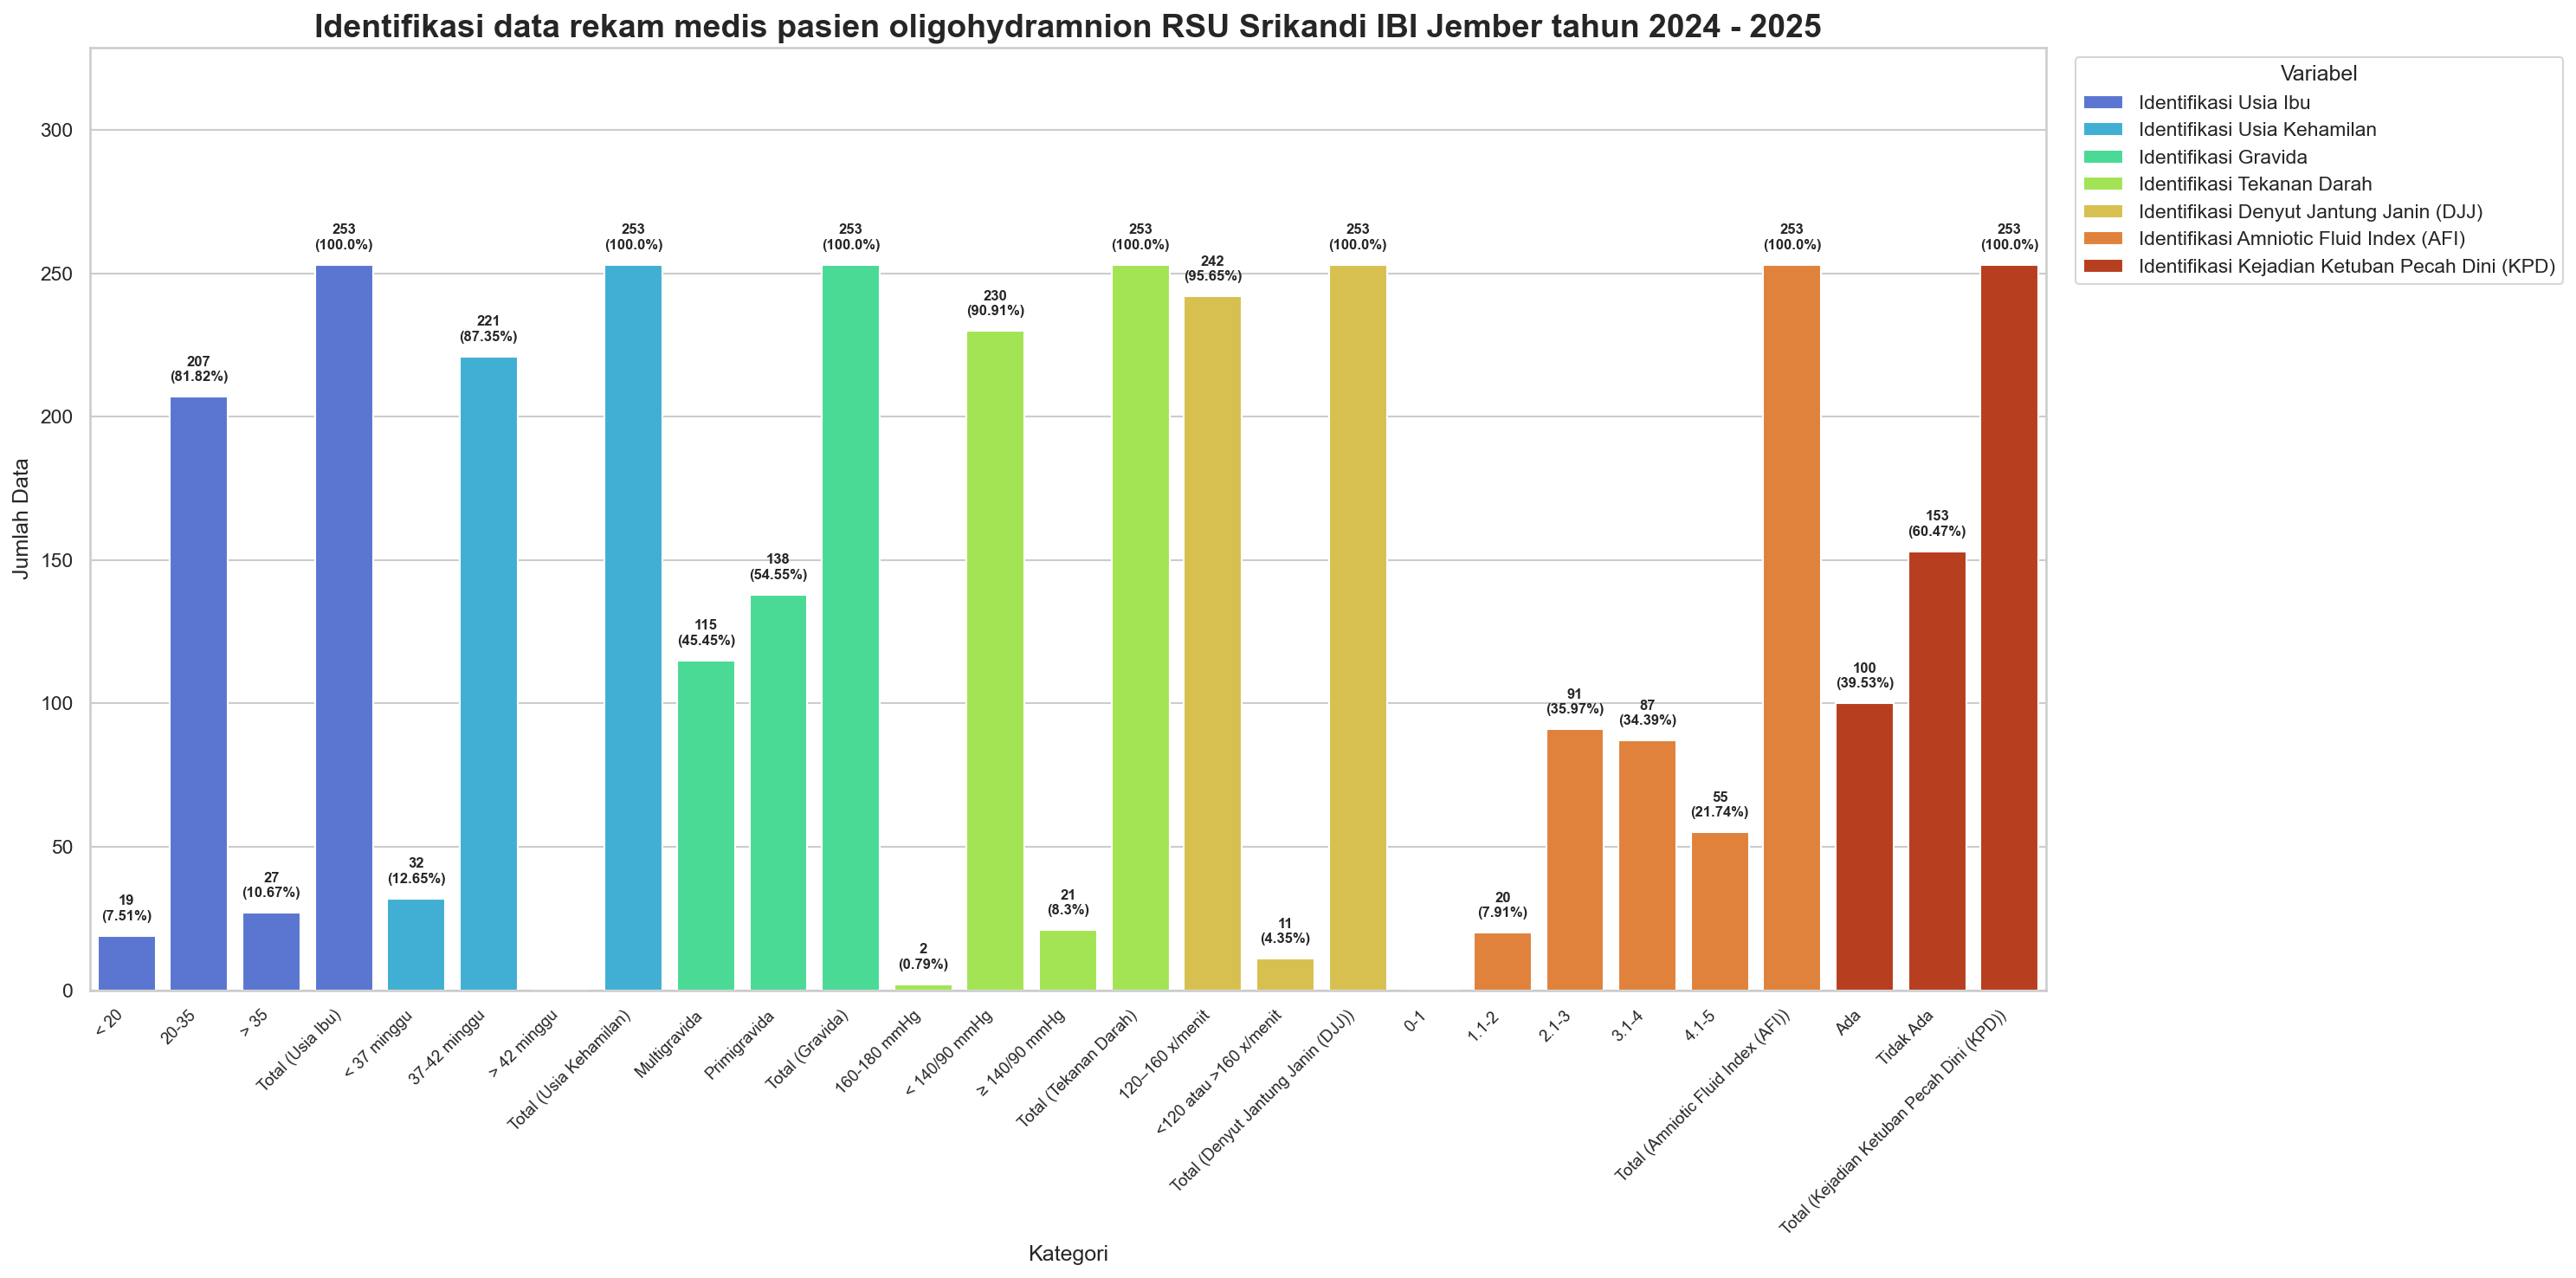

Total data mentah : 255
Data valid        : 253
Data invalid      : 2
Output tersimpan di folder outputs.


,No,Nomor RM,Usia Ibu,Usia Kehamilan,Gravida,Tekanan Darah,Denyut Jantung Janin,Nilai AFI,Kejadian KPD
0,1,054121,0.517241,0.842105,1.0,0.0,0.0,0.380805,1.0
1,2,065046,0.448276,0.877193,1.0,0.5,0.0,0.380805,1.0
2,3,078533,0.655172,0.842105,1.0,0.0,0.0,0.380805,1.0
3,4,083531,0.275862,0.877193,0.0,0.0,0.0,0.380805,1.0
4,5,079120,0.758621,0.771930,1.0,0.0,0.0,0.071207,0.0


In [24]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df = standardize_columns(raw_df)
transformed_df = transform_rows(raw_df)

valid_df = transformed_df.loc[transformed_df["Status Validasi"] == "valid"].copy()
invalid_df = transformed_df.loc[transformed_df["Status Validasi"] == "invalid"].copy()

# Visualisasi Identifikasi Data sebelum normalisasi
visualize_identifikasi(valid_df)

output_preprocessing, output_detail, min_values, max_values = build_normalized_outputs(valid_df)
invalid_export_columns = list(raw_df.columns) + [
    "Gravida Asli",
    "Denyut Jantung Janin Asli",
    "Sistolik",
    "Diastolik",
    "Status Validasi",
    "Alasan Invalid",
]
invalid_export_columns = [column for column in invalid_export_columns if column in invalid_df.columns]
invalid_export = invalid_df[invalid_export_columns].copy()
output_preprocessing = output_preprocessing.round(6)
output_detail = output_detail.round(6)
invalid_export.to_csv(OUTPUT_DIR / "output_data_invalid.csv", index=False, encoding="utf-8-sig")
output_preprocessing.to_csv(OUTPUT_DIR / "output_preprocessing.csv", index=False, encoding="utf-8-sig")
output_detail.to_csv(OUTPUT_DIR / "output_preprocessing_detail.csv", index=False, encoding="utf-8-sig")
metadata = {
    "total_rows_raw": int(len(raw_df)),
    "valid_rows": int(len(valid_df)),
    "invalid_rows": int(len(invalid_df)),
    "feature_columns": FEATURE_COLUMNS,
    "min_values": {column: float(value) for column, value in min_values.items()},
    "max_values": {column: float(value) for column, value in max_values.items()},
}
artifacts_dir = OUTPUT_DIR / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
(artifacts_dir / "preprocessing_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)
print(f"Total data mentah : {len(raw_df)}")
print(f"Data valid        : {len(valid_df)}")
print(f"Data invalid      : {len(invalid_df)}")
print("Output tersimpan di folder outputs.")
output_preprocessing.head()